<a href="https://colab.research.google.com/github/amityadav0029/algo/blob/main/web.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import requests

# url = "https://pastebin.com/raw/fBkgrbQw"

# headers = {
#     "User-Agent": "Mozilla/5.0"
# }

# res = requests.get(url, headers=headers)

# print(res.text)


   Unnamed: 0    Artist                                        Url_spotify  \
0           0  Gorillaz  https://open.spotify.com/artist/3AA28KZvwAUcZu...   
1           1  Gorillaz  https://open.spotify.com/artist/3AA28KZvwAUcZu...   
2           2  Gorillaz  https://open.spotify.com/artist/3AA28KZvwAUcZu...   
3           3  Gorillaz  https://open.spotify.com/artist/3AA28KZvwAUcZu...   
4           4  Gorillaz  https://open.spotify.com/artist/3AA28KZvwAUcZu...   

                                           Track  \
0                                 Feel Good Inc.   
1                                Rhinestone Eyes   
2  New Gold (feat. Tame Impala and Bootie Brown)   
3                             On Melancholy Hill   
4                                 Clint Eastwood   

                                           Album Album_type  \
0                                     Demon Days      album   
1                                  Plastic Beach      album   
2  New Gold (feat. Tame Impal

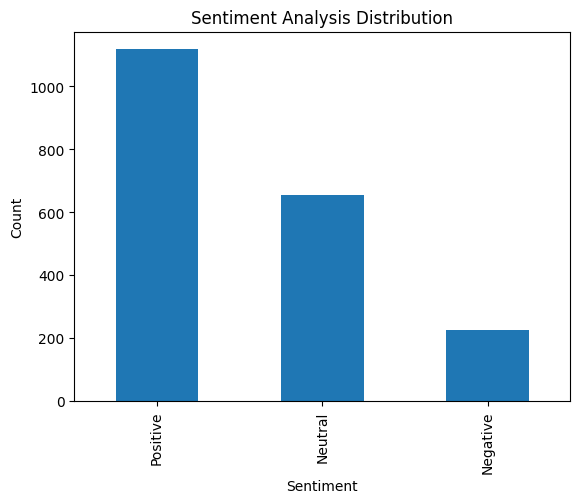

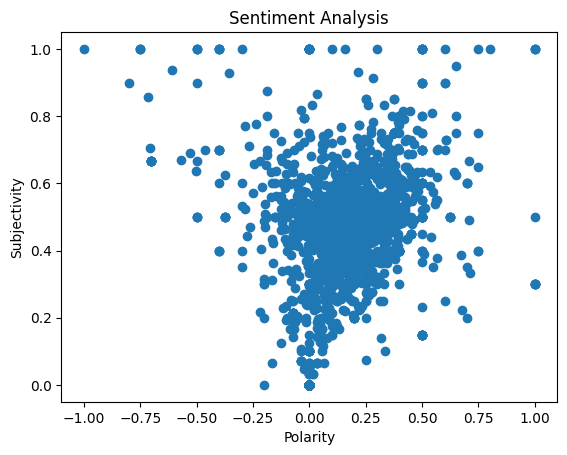

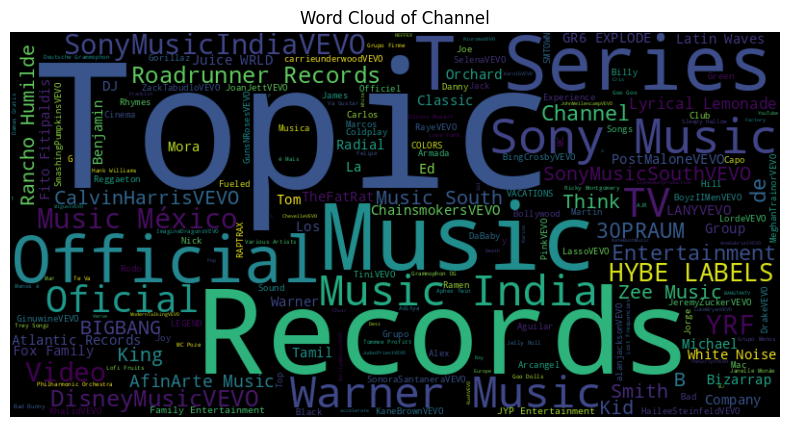

In [1]:


#pip install numpy pandas matplotlib seaborn textblob wordcloud
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from wordcloud import WordCloud
import warnings
warnings.filterwarnings("ignore")



df = pd.read_csv("Spotify_Youtube.csv")

# Basic Info
print(df.head())
print(df.info())
print("Shape:", df.shape)
print("Data Types:\n", df.dtypes)
print("Null Values:\n", df.isnull().sum())

# Drop null Description
df = df.dropna(subset=['Description'])

# Sample Data
samp = df.sample(2000, random_state=42)
print("Sample Shape:", samp.shape)

# Sentiment Polarity
pol = []
for i in samp['Description']:
    analysis = TextBlob(str(i))
    sentiment = analysis.sentiment.polarity
    pol.append(sentiment)

samp['pol'] = pol

print(samp[['Description', 'pol']].head())

# Sentiment Label Function
def get_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

# Apply Sentiment Label
samp['Sentiment'] = samp['pol'].apply(get_sentiment)
print(samp.head())

# Bar Plot
samp['Sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Analysis Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

# Subjectivity
subjectivity = []
for i in samp['Description']:
    analysis = TextBlob(str(i))
    subjectivity.append(analysis.sentiment.subjectivity)

samp['subjectivity'] = subjectivity

# Scatter Plot
plt.scatter(samp['pol'], samp['subjectivity'])
plt.title("Sentiment Analysis")
plt.xlabel("Polarity")
plt.ylabel("Subjectivity")
plt.show()

# Word Cloud
text = " ".join(str(i) for i in samp['Channel'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='black'
).generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Channel")
plt.show()










In [2]:

from itertools import combinations

# Transactions dataset
transactions = [
    ['milk', 'bread', 'butter'],
    ['bread', 'butter'],
    ['milk', 'bread'],
    ['milk', 'butter'],
    ['bread']
]

min_support = 2

# Function to calculate support
def get_support(itemset):
    count = 0
    for transaction in transactions:
        if set(itemset).issubset(transaction):
            count += 1
    return count

# Apriori Algorithm
def apriori():
    # Get all unique items
    items = set(item for transaction in transactions for item in transaction)

    # Start with single-item itemsets
    current_itemsets = [[item] for item in items]
    frequent_itemsets = []
    k = 1

    while current_itemsets:
        frequent = []

        # Check support
        for itemset in current_itemsets:
            support = get_support(itemset)
            if support >= min_support:
                frequent.append(itemset)
                frequent_itemsets.append((itemset, support))

        # Generate next candidates
        k += 1
        next_itemsets = []

        for i in range(len(frequent)):
            for j in range(i + 1, len(frequent)):
                candidate = list(set(frequent[i]) | set(frequent[j]))

                if len(candidate) == k and candidate not in next_itemsets:
                    next_itemsets.append(candidate)

        current_itemsets = next_itemsets

    return frequent_itemsets


# Run algorithm
result = apriori()

print("Frequent Itemsets:")
for itemset, support in result:
    print(itemset, "-> Support:", support)

Frequent Itemsets:
['butter'] -> Support: 3
['bread'] -> Support: 4
['milk'] -> Support: 3
['butter', 'bread'] -> Support: 2
['butter', 'milk'] -> Support: 2
['bread', 'milk'] -> Support: 2


In [3]:


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
#pip install scikit-learn
# Input documents
doc1 = """Machine learning is a subset of artificial intelligence
that helps systems learn from data."""

# 4: Develop a Programme for Deep search implementation to detect plagiarism in document online

doc2 = """Machine learning is part of artificial intelligence
which allows systems to learn from data."""

# Convert text to TF-IDF vectors
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform([doc1, doc2])

# Compute cosine similarity
similarity = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])

# Convert to percentage
score = similarity[0][0] * 100

# Output result
print(f"Similarity Score: {score:.2f}%")

if score > 60:
    print("Possible Plagiarism Detected")
else:
    print("Low Similarity (Safe)")

Similarity Score: 59.22%
Low Similarity (Safe)
